<h1 style="text-align: center;">Bank Marketing Term Deposit Subscription Prediction</h1>
<h3 style="text-align: center;"><b>Gamma Group</b></h3>

---

# **Section 0. Setup**

## **0.1 Import library**

In [216]:
# Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import joblib
import sklearn
import lightgbm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.feature_selection import SelectKBest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, f1_score, fbeta_score, roc_auc_score, recall_score, make_scorer
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 9
pd.set_option("display.max_columns", None)

## **0.2 Global Configuration**

In [178]:
RANDOM_STATE = 9
pd.set_option('display.max_columns', None)

# **Section 1. Business Understanding**

## **1.1 Context**

&emsp;&emsp;&emsp;Sebuah bank di Portugal menjalankan kampanye telemarketing outbound untuk menawarkan produk deposito berjangka (term deposit) kepada nasabah yang sudah ada. Dalam kampanye ini, agen menghubungi nasabah melalui telepon secara langsung dan mencatat apakah nasabah bersedia berlangganan produk tersebut atau tidak.

&emsp;&emsp;&emsp;Deposito berjangka merupakan salah satu produk simpanan utama bagi bank — nasabah yang berlangganan akan mengunci dana mereka dalam jangka waktu tertentu dengan bunga tetap, memberikan **likuiditas yang stabil dan terencana bagi bank**. Semakin banyak nasabah yang berlangganan, semakin baik posisi pendanaan bank.

**Stakeholder utama proyek ini:**
- **Marketing / Campaign Team** — sebagai pengguna langsung hasil model, tim ini bertanggung jawab menentukan nasabah mana yang akan dihubungi dalam setiap siklus kampanye. Model prediktif dibutuhkan agar keputusan target tidak lagi bersifat massal, melainkan berdasarkan skor potensi konversi tiap nasabah — sehingga anggaran dan waktu agen dapat difokuskan pada nasabah dengan kemungkinan berlangganan tertinggi

**Stakeholder pendukung:**
- **Call Center Manager** — memanfaatkan hasil prioritisasi daftar panggilan yang lebih cerdas, supaya produktivitas agen meningkat dan conversion rate kampanye naik.
- **Management / Business Owner** — membutuhkan estimasi ROI kampanye dan potensi peningkatan revenue deposito jika model digunakan dibanding pendekatan random calling saat ini.

&emsp;&emsp;&emsp;Saat ini, proses penentuan siapa yang dihubungi masih bersifat massal dan tidak tersegmentasi — bank menghubungi daftar nasabah secara luas tanpa mempertimbangkan profil atau histori interaksi mereka secara sistematis. Berdasarkan data historis kampanye pada dataset ini, conversion rate (CVR) subscription produk term deposit sebesar 11,27% — artinya sekitar 89% panggilan tidak menghasilkan konversi dan berujung pada pemborosan biaya operasional.

&emsp;&emsp;&emsp;Angka tersebut sebanding dengan rata-rata conversion-to-sale rate telemarketing ~10% yang dilaporkan oleh penelitian Telecom Express terhadap 1.000 perusahaan dari berbagai sektor (Telecom Express via Campaign Live, 2003). Perlu dicatat bahwa benchmark tersebut bersifat lintas industri dan tidak secara spesifik merepresentasikan telemarketing produk deposito perbankan, sehingga CVR 11,27% dapat dikategorikan sebagai performa yang relatif sebanding dengan rata-rata industri — bukan exceptional — yang berarti masih terdapat ruang signifikan untuk peningkatan efisiensi melalui targeting yang lebih akurat.

### **1.11 Kenapa Machine Learning?**
 Pendekatan machine learning dipilih karena karakteristik masalah ini memang tidak cocok diselesaikan dengan segmentasi manual atau rule-based system. Ada beberapa pertimbangan yang mendukung alasan ini.

1. Polanya terlalu kompleks untuk dirumuskan manual
20 fitur dari tiga domain berbeda (demografis, histori kampanye, latar belakang ekonomi) berinteraksi satu sama lain. Nasabah pensiunan yang pernah dikonversi sebelumnya berperilaku sangat berbeda dari pensiunan yang belum pernah dihubungi — tapi secara kasat mata keduanya terlihat sama. Pola seperti ini tidak bisa ditangkap dengan aturan manual.

2. 41.000+ nasabah — penilaian satu per satu tidak mungkin
Tidak ada tim marketing yang bisa menilai potensi konversi setiap nasabah secara individual sebelum tiap kampanye. ML menghasilkan skor probabilitas per nasabah secara otomatis, dan itu langsung jadi dasar prioritas panggilan.

3. Kondisi pasar berubah, aturan statis tidak
Euribor, CPI, employment rate — semua bergerak. Aturan yang relevan bulan lalu belum tentu relevan bulan depan. Model ML bisa di-retrain mengikuti kondisi terkini.

4. Rule-based tidak bisa menghasilkan ranking
Aturan manual hanya menghasilkan dua pilihan: hubungi atau tidak. Tim kampanye butuh ranked list — urutan nasabah dari yang paling berpotensi ke yang paling kecil — supaya kapasitas panggilan yang terbatas bisa dipakai seefisien mungkin. Ini hanya bisa dari model prediktif.

5. Sudah terbukti di kasus yang sama
Moro et al. (2014) menunjukkan bank bisa menangkap 79% konversi hanya dengan menghubungi 50% nasabah teratas. Separuh panggilan, hampir semua konversi tetap tertangkap.

## **1.2 Problem Statements**

Kampanye telemarketing deposito bank masih dilakukan secara massal tanpa segmentasi, menghasilkan conversion rate (~11%). Kondisi ini menunjukkan bahwa sebagian besar kapasitas kontak digunakan untuk menghubungi nasabah yang belum tentu memiliki ketertarikan terhadap produk deposito, sementara nasabah dengan potensi konversi tinggi berisiko tidak teridentifikasi dan terlewat. Oleh karena itu, diperlukan pendekatan berbasis data melalui model prediktif yang mampu mengidentifikasi dan memprioritaskan nasabah berdasarkan kemungkinan mereka melakukan subscription, sehingga bank dapat meningkatkan peluang konversi sekaligus menggunakan kapasitas kontak telemarketing secara lebih efisien.

## **1.3 Goals**

Dari problem statement di atas, proyek ini punya tiga tujuan utama:

- Membangun model klasifikasi yang bisa memprediksi probabilitas seorang nasabah akan subscribe deposito berjangka — outputnya bukan sekadar label yes/no, tapi skor per nasabah yang bisa langsung dipakai tim kampanye untuk menyusun daftar prioritas panggilan.
- Mengidentifikasi faktor-faktor yang paling menentukan keputusan subscribe — bukan hanya untuk keperluan interpretasi model, tapi sebagai dasar rekomendasi konkret: segmen mana yang perlu diprioritaskan, dan pendekatan seperti apa yang relevan untuk tiap segmen.
- Mengukur dampak bisnis nyata dari penggunaan model ini — seberapa banyak konversi yang bisa ditangkap dibanding random calling, dan apakah efisiensi jumlah panggilannya juga membaik. Ini yang akhirnya menjawab apakah model ini worth deploying atau tidak.

## **1.4 Analytical Approach**

&emsp;&emsp;&emsp;Target yang ingin diprediksi bersifat kategorikal biner (**y**: `yes` = berlangganan, `no` = tidak berlangganan), sehingga pendekatan analitis yang digunakan adalah **klasifikasi (binary classification)**.

Alur pendekatan yang akan dijalankan:
1. **Data Understanding & EDA** — memahami karakteristik nasabah yang berlangganan vs tidak berlangganan, serta memeriksa keseimbangan kelas target (~11% `yes` vs ~89% `no`).
2. **Data Preparation** — membersihkan data, menangani nilai yang tidak diketahui (`unknown`), encoding variabel kategorikal, scaling, dan menangani *class imbalance* karena target sangat tidak seimbang.
3. **Model Benchmarking** — membandingkan beberapa algoritma klasifikasi (Logistic Regression sebagai baseline, serta Decision Tree / Random Forest / Boosting sebagai kandidat performa lebih tinggi) menggunakan cross-validation.
4. **Model Tuning** — melakukan hyperparameter tuning pada model terbaik dari tahap benchmarking.
5. **Model Interpretation** — menggunakan feature importance / SHAP untuk menjawab pertanyaan faktor apa yang paling berpengaruh (Section 1.2 poin 2).
6. **Business Simulation** — menerjemahkan output probabilitas model menjadi skenario bisnis konkret: seberapa besar potensi konversi (dan estimasi pendapatan deposito) yang berhasil ditangkap, serta bagaimana efisiensi jumlah panggilan dibanding pendekatan random calling (Section 8).


## **1.5 Metric Evaluation**

**Business Metric**

&emsp;&emsp;&emsp;Ada dua jenis kesalahan prediksi yang punya konsekuensi biaya berbeda dalam konteks kampanye telemarketing ini:
- **False Negative (FN)** — nasabah yang sebenarnya akan berlangganan tapi diprediksi tidak berlangganan → agen tidak menghubungi nasabah tersebut → **kehilangan potensi konversi dan pendapatan deposito**.
- **False Positive (FP)** — nasabah yang sebenarnya tidak akan berlangganan tapi diprediksi akan berlangganan → agen tetap menghubungi namun berujung penolakan → **biaya panggilan yang terbuang**, namun lebih kecil dibandingkan kehilangan peluang konversi.

&emsp;&emsp;&emsp;Karena **cost of FN > cost of FP** dalam konteks ini — setiap konversi yang terlewat adalah hilangnya pendapatan deposito jangka panjang — evaluasi model diarahkan untuk meminimalkan False Negative sambil tetap menjaga efisiensi panggilan. Diasumsikan potensi pendapatan dari margin bunga selama masa tenor deposito seorang nasabah secara signifikan lebih besar dibanding biaya operasional satu kali panggilan telepon, sehingga kehilangan satu peluang konversi (FN) dinilai lebih costly dibanding satu panggilan yang berujung penolakan (FP).

**Machine Learning Metric**
**ROC-AUC** digunakan sebagai **metrik utama (scoring metric)** pada tahap model benchmarking maupun hyperparameter tuning — mengukur kemampuan model dalam meranking nasabah berpotensi di atas nasabah tidak berpotensi secara threshold-independent, ideal untuk skenario *lead scoring* kampanye.
- **F2-Score** dihitung sebagai **metrik pelengkap (monitoring metric)** pada kedua tahap tersebut, untuk memastikan model yang dipilih berdasarkan ROC-AUC juga tetap selaras dengan prioritas bisnis (recall-oriented, sesuai cost of FN > cost of FP di atas), meski tidak digunakan sebagai dasar seleksi/tuning.
- **Precision-Recall AUC** dipantau sebagai pelengkap — lebih informatif dibanding ROC-AUC pada kondisi *class imbalance* seperti dataset ini (~11% kelas positif).
- **Confusion Matrix** dan **Classification Report** digunakan pada evaluasi model final untuk analisis kesalahan secara menyeluruh, termasuk verifikasi pencapaian target Recall dan Precision sesuai Success Criteria.


## **1.6 Success Criteria**

&emsp;&emsp;&emsp;Model dinyatakan layak digunakan apabila memenuhi kriteria berikut pada data testing:
- **ROC-AUC minimal 0.80** — memastikan model memiliki kemampuan diskriminasi yang baik antara nasabah yang akan berlangganan dan yang tidak.
- **Recall minimal 70%** — memastikan mayoritas nasabah yang benar-benar akan berlangganan berhasil teridentifikasi dan masuk ke daftar prioritas panggilan.
- **Precision minimal 40%** — menjaga efisiensi kampanye agar tidak terlalu banyak anggaran terbuang untuk panggilan ke nasabah yang tidak berpotensi.
- **F2-Score model mengungguli baseline** secara signifikan — model harus lebih baik dari sekadar menebak semua orang akan berlangganan atau menggunakan simple rule-based threshold, sekaligus menjadi bukti bahwa model tetap selaras dengan prioritas recall meski dioptimasi menggunakan ROC-AUC.
- **Dampak bisnis** — model harus mampu menunjukkan peningkatan potensi konversi (dan estimasi pendapatan deposito) yang berhasil ditangkap dibanding pendekatan random calling, dengan tetap memperhatikan efisiensi jumlah panggilan yang dilakukan (dibuktikan lewat business simulation di Section 8).

# **Section 2. Data Understanding**

## **2.1 General Information**

In [179]:
# Load dataset
df_raw = pd.read_csv("../Dataset/bank-additional-full.csv", sep=";")
df_raw

print(f"Dimensi dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.info()

Dimensi dataset: 41188 baris x 21 kolom
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  floa

In [180]:
df_raw.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,380,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,50,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## **2.2 Feature Information**

| Feature | Tipe | Deskripsi | Dampak Bisnis |
|---|---|---|---|
| `age` | Numerik | Usia nasabah | Segmentasi usia yang lebih responsif |
| `job` | Kategorikal | Jenis pekerjaan | Menentukan segmen profesi potensial |
| `marital` | Kategorikal | Status pernikahan | Mendukung segmentasi customer |
| `education` | Kategorikal | Pendidikan | Mengidentifikasi profil nasabah potensial |
| `default` | Kategorikal | Status kredit default | Memberi konteks risiko finansial |
| `housing` | Kategorikal | Pinjaman perumahan | Memberi konteks kondisi finansial |
| `loan` | Kategorikal | Pinjaman pribadi | Membantu memahami beban finansial |
| `contact` | Kategorikal | Channel komunikasi | Optimasi channel campaign |
| `month` | Kategorikal | Bulan kontak terakhir | Optimasi timing campaign |
| `day_of_week` | Kategorikal | Hari kontak terakhir | Optimasi waktu campaign |
| `duration` | Numerik | Durasi kontak terakhir (detik) | Proxy engagement; **berpotensi leakage** untuk targeting sebelum kontak |
| `campaign` | Numerik | Jumlah kontak pada campaign saat ini | Optimasi frekuensi kontak |
| `pdays` | Numerik | Hari sejak kontak campaign sebelumnya | Menentukan timing follow-up |
| `previous` | Numerik | Jumlah kontak sebelum campaign saat ini | Menggambarkan intensitas historis |
| `poutcome` | Kategorikal | Hasil campaign sebelumnya | Prioritas nasabah berdasarkan respons sebelumnya |
| `emp.var.rate` | Numerik | Employment variation rate | Konteks kondisi ekonomi |
| `cons.price.idx` | Numerik | Consumer Price Index | Konteks inflasi/harga |
| `cons.conf.idx` | Numerik | Consumer Confidence Index | Konteks kepercayaan konsumen |
| `euribor3m` | Numerik | Suku bunga Euribor 3 bulan | Konteks kondisi suku bunga |
| `nr.employed` | Numerik | Indikator employment | Konteks kondisi ekonomi |
| `y` | Target | Subscription deposito: yes/no | Target bisnis utama |

## **2.3 Statistics Summary**

In [181]:
df_raw.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [182]:
# Cek distribusi kategori
cat_cols = df_raw.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    print("=" * 60)
    print(f"Kolom: {col}")
    print("=" * 60)
    result = pd.DataFrame({
        "Count": df_raw[col].value_counts(),
        "Percentage (%)": df_raw[col].value_counts(normalize=True).mul(100).round(2)
    })
    display(result)

Kolom: job


,Count,Percentage (%)
job,,
admin.,10422,25.30
blue-collar,9254,22.47
technician,6743,16.37
services,3969,9.64
management,2924,7.10
retired,1720,4.18
entrepreneur,1456,3.54
self-employed,1421,3.45
housemaid,1060,2.57


Kolom: marital


,Count,Percentage (%)
marital,,
married,24928,60.52
single,11568,28.09
divorced,4612,11.20
unknown,80,0.19


Kolom: education


...

,Count,Percentage (%)
day_of_week,,
thu,8623,20.94
mon,8514,20.67
wed,8134,19.75
tue,8090,19.64
fri,7827,19.00


Kolom: poutcome


,Count,Percentage (%)
poutcome,,
nonexistent,35563,86.34
failure,4252,10.32
success,1373,3.33


Kolom: y


,Count,Percentage (%)
y,,
no,36548,88.73
yes,4640,11.27


# **Section 3. Data Cleaning**

## **3.1. Duplicated Values**

In [183]:
df = df_raw.copy()

# Cek duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)

duplicate_summary = pd.DataFrame({
    "Duplicate Count": [duplicate_count],
    "Duplicate (%)": [duplicate_pct]
}, index=["Total"])

display(duplicate_summary)

# Hapus duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape setelah duplicate removal:", df.shape)

,Duplicate Count,Duplicate (%)
Total,12,0.03


Shape setelah duplicate removal: (41176, 21)


## **3.2. Missing Values**

In [184]:
# Missing values
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

display(missing_summary[missing_summary["Missing Count"] > 0])

# Dataset Bank Marketing ini menggunakan 'unknown' sebagai kategori,
# bukan NaN, sehingga unknown perlu dipertimbangkan sebagai missing information.
unknown_summary = pd.DataFrame({
    "Unknown Count": [(df[col] == "unknown").sum() if df[col].dtype == "object" else 0 for col in df.columns]
}, index=df.columns)
unknown_summary["Unknown (%)"] = (unknown_summary["Unknown Count"] / len(df) * 100).round(2)

display(unknown_summary[unknown_summary["Unknown Count"] > 0].sort_values("Unknown Count", ascending=False))

,Missing Count,Missing (%)


,Unknown Count,Unknown (%)
default,8596,20.88
education,1730,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


## **3.3. "Unknown" Values**

In [185]:
cols_to_impute = ['education', 'housing', 'loan', 'job', 'marital']

for col in cols_to_impute:
    mode_val = df[df[col] != 'unknown'][col].mode()[0]
    before = (df[col] == 'unknown').sum()
    df[col] = df[col].replace('unknown', mode_val)
    print(f"{col}: {before} 'unknown' -> diganti dengan modus ('{mode_val}')"  )

# 'default' dipertahankan sebagai kategori ketiga (unknown = informasi tersendiri)
print(f"\ndefault: {(df['default'] == 'unknown').sum()} 'unknown' dipertahankan sebagai kategori.")
print("\nShape setelah imputasi unknown:", df.shape)

education: 1730 'unknown' -> diganti dengan modus ('university.degree')
housing: 990 'unknown' -> diganti dengan modus ('yes')
loan: 990 'unknown' -> diganti dengan modus ('no')
job: 330 'unknown' -> diganti dengan modus ('admin.')
marital: 80 'unknown' -> diganti dengan modus ('married')

default: 8596 'unknown' dipertahankan sebagai kategori.

Shape setelah imputasi unknown: (41176, 21)


## **3.4. Duration = 0**

In [186]:
before = len(df)
df = df[df['duration'] > 0].reset_index(drop=True)
after = len(df)

print(f"Before deletion: {before - after}")
print(f"Shape after deletion: {df.shape}")

Before deletion: 4
Shape after deletion: (41172, 21)


## **3.5. Pdays = 999**

In [187]:
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, np.nan)

print("Distribution 'was_previously_contacted':")
print(df['was_previously_contacted'].value_counts())
print(f"\npdays NaN after flag: {df['pdays'].isna().sum()}")
print(f"Shape after transformation of pdays: {df.shape}")

Distribution 'was_previously_contacted':
was_previously_contacted
0    39657
1     1515
Name: count, dtype: int64

pdays NaN after flag: 39657
Shape after transformation of pdays: (41172, 22)


## **3.6. Capping Outlier `campaign`**

In [188]:
p95 = df['campaign'].quantile(0.95)
before_max = df['campaign'].max()
df['campaign'] = df['campaign'].clip(upper=p95)
after_max = df['campaign'].max()

print(f"campaign before capping | max: {before_max}")
print(f"campaign after capping  | max: {after_max} (capped at P95 = {p95})")
print(df['campaign'].describe().round(2))

campaign before capping | max: 56
campaign after capping  | max: 7 (capped at P95 = 7.0)
count    41172.00
mean         2.33
std          1.70
min          1.00
25%          1.00
50%          2.00
75%          3.00
max          7.00
Name: campaign, dtype: float64


## **3.7. Menghapus Baris `age < 18`**

In [189]:
before = len(df)
df = df[df['age'] >= 18].reset_index(drop=True)
after = len(df)

print(f"Number of age < 18: {before - after}")
print(f"Shape after deletion: {df.shape}")

Number of age < 18: 5
Shape after deletion: (41167, 22)


## **3.8 Summary Data Cleaning**

In [190]:
print("=" * 50)
print("RINGKASAN DATA CLEANING")
print("=" * 50)
print(f"Shape awal (df_raw)     : {df_raw.shape}")
print(f"Shape akhir (df bersih) : {df.shape}")
print(f"Total baris dihapus     : {df_raw.shape[0] - df.shape[0]}")

print("\n--- Missing / Unknown Values ---")
unknown_remaining = pd.DataFrame({
    "Unknown Count": [(df[col] == "unknown").sum() if df[col].dtype == "object" else 0 for col in df.columns]
}, index=df.columns)
unknown_remaining = unknown_remaining[unknown_remaining["Unknown Count"] > 0]
if len(unknown_remaining) == 0:
    print("Tidak ada 'unknown' tersisa (selain kolom 'default' yang disengaja dipertahankan).")
else:
    print(unknown_remaining)

print("\n--- Fitur Baru ---")
print("'was_previously_contacted' ditambahkan:", 'was_previously_contacted' in df.columns)

print("\n--- Null Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Tipe Data Akhir ---")
print(df.dtypes)

RINGKASAN DATA CLEANING
Shape awal (df_raw)     : (41188, 21)
Shape akhir (df bersih) : (41167, 22)
Total baris dihapus     : 21

--- Missing / Unknown Values ---
         Unknown Count
default           8596

--- Fitur Baru ---
'was_previously_contacted' ditambahkan: True

--- Null Values ---
pdays    39655
dtype: int64

--- Tipe Data Akhir ---
age                           int64
job                          object
marital                      object
education                    object
default                      object
housing                      object
loan                         object
contact                      object
month                        object
day_of_week                  object
duration                      int64
campaign                      int64
pdays                       float64
previous                      int64
poutcome                     object
emp.var.rate                float64
cons.price.idx              float64
cons.conf.idx               float64
euri

# **Section 4. Exploratory Data Analysis (EDA)**

## **4.1 Univariate Analysis**

### 4.1.1 Distribusi Target (Deposit Subscription)

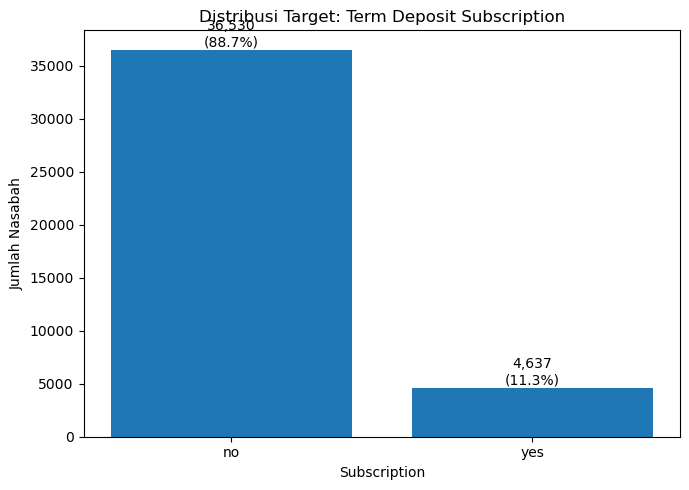

In [191]:
# Target distribution
target_dist = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True).mul(100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(target_dist.index, target_dist.values)
ax.set_title("Distribusi Target: Term Deposit Subscription")
ax.set_xlabel("Subscription")
ax.set_ylabel("Jumlah Nasabah")
for bar, val, pct in zip(bars, target_dist.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f"{val:,}\n({pct:.1f}%)",
            ha="center", va="bottom")
plt.tight_layout()
plt.show()

### 4.1.2 Distribusi Fitur Numerik

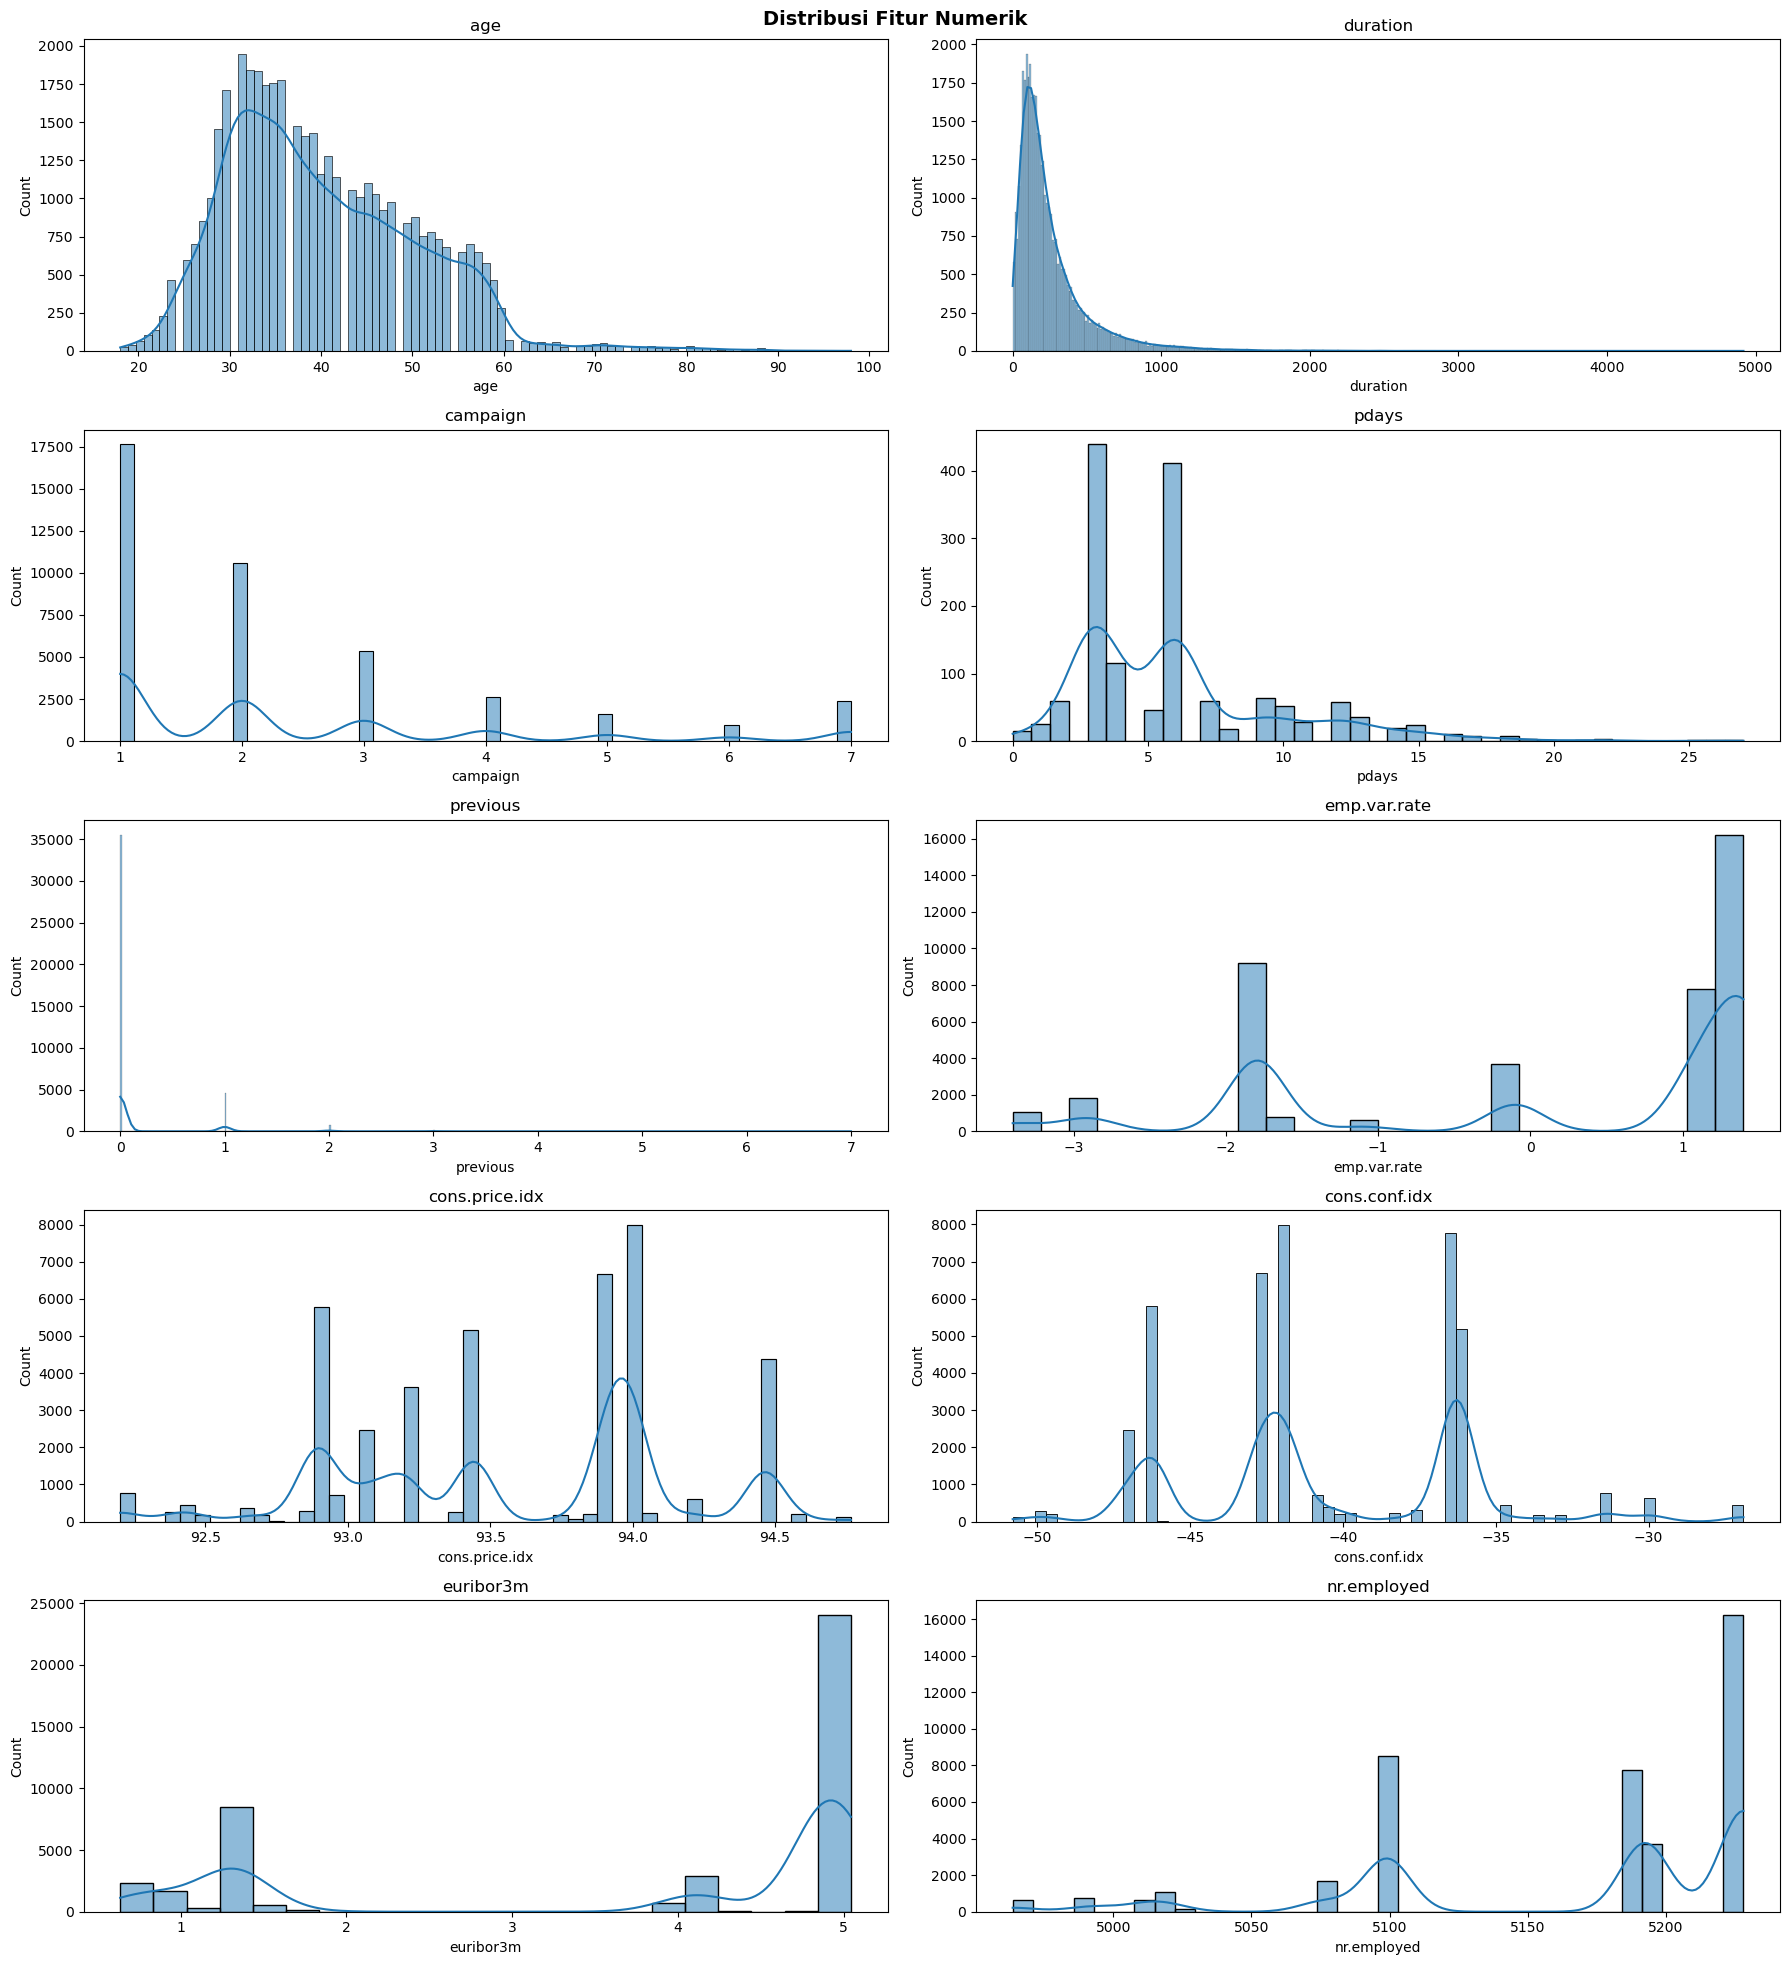

In [192]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [c for c in numeric_cols if c != "y"]

fig, axes = plt.subplots(5, 2, figsize=(18, 20))
for ax, col in zip(axes.flat, numeric_features):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [193]:
df["pdays"].dtype

dtype('float64')

### 4.1.3 Distribusi Fitur Kategorikal

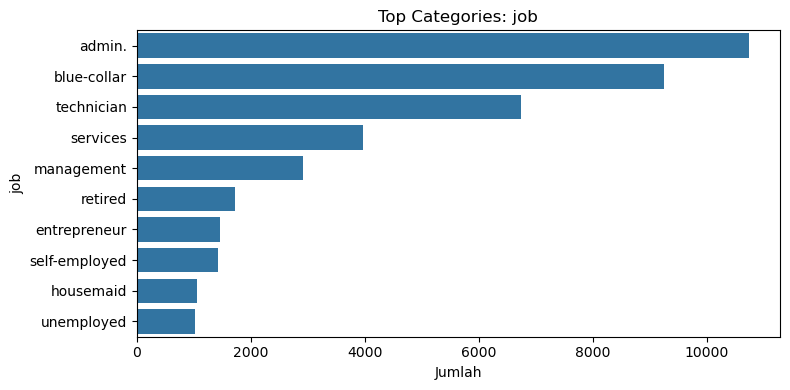

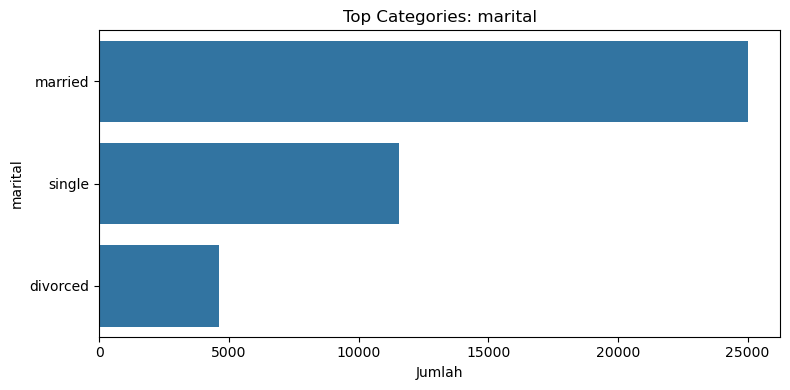

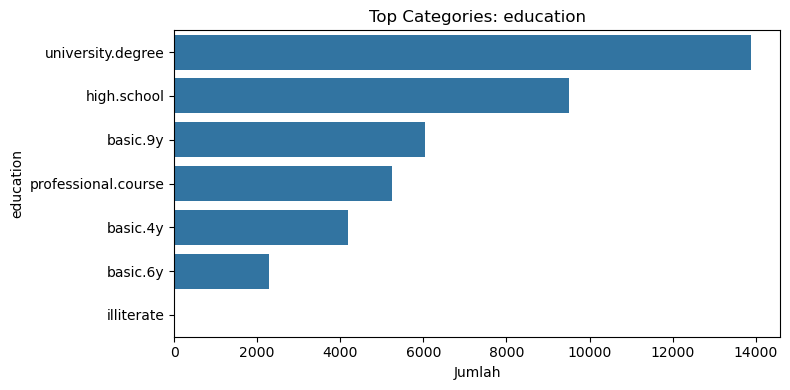

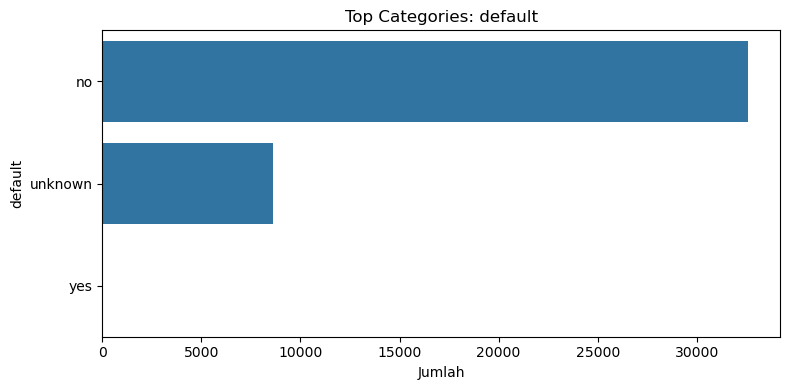

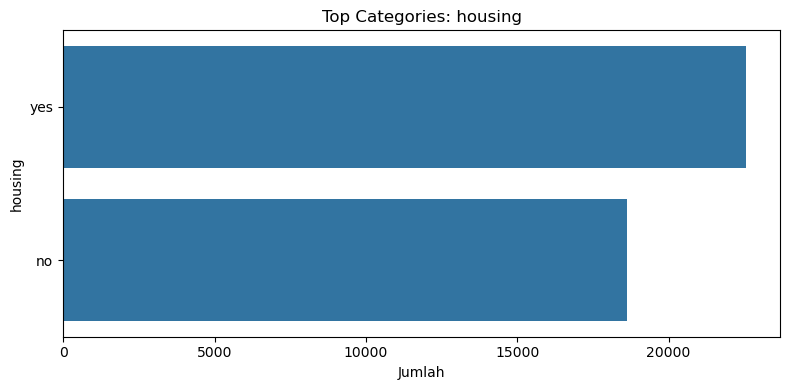

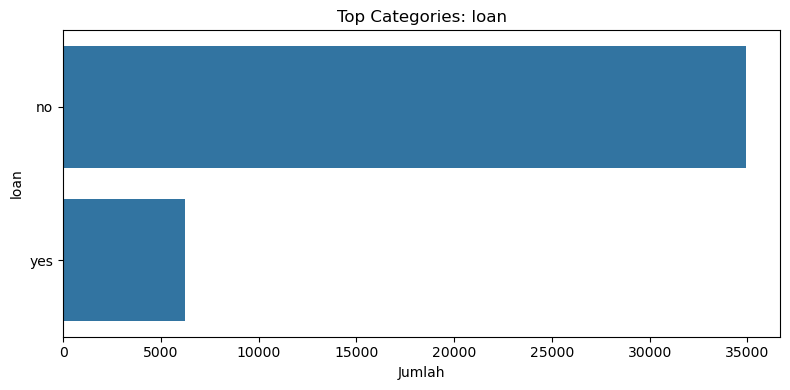

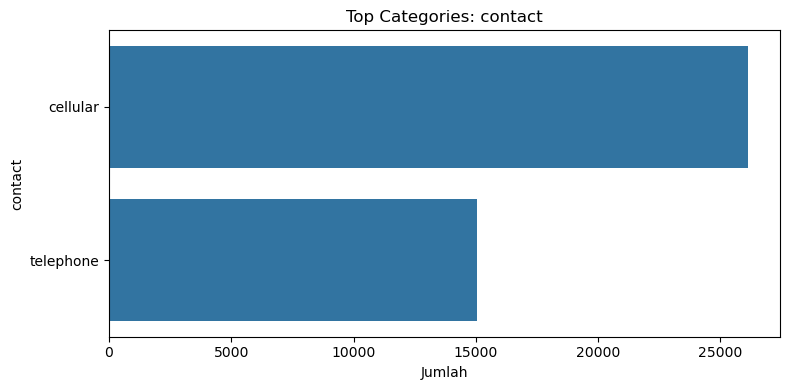

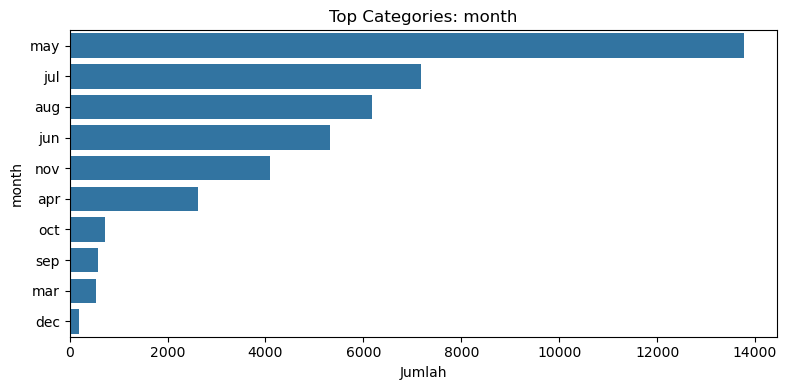

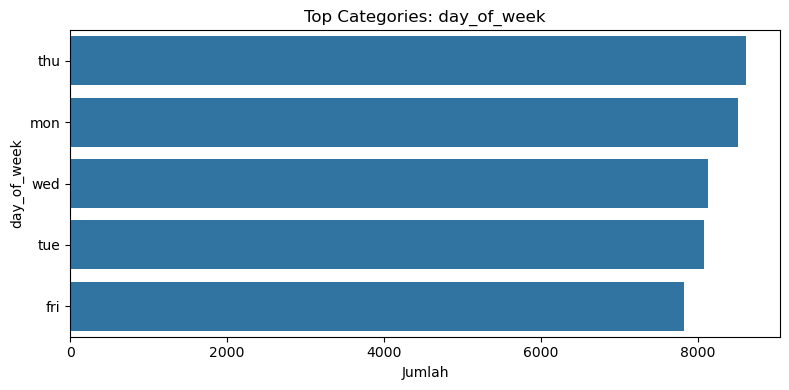

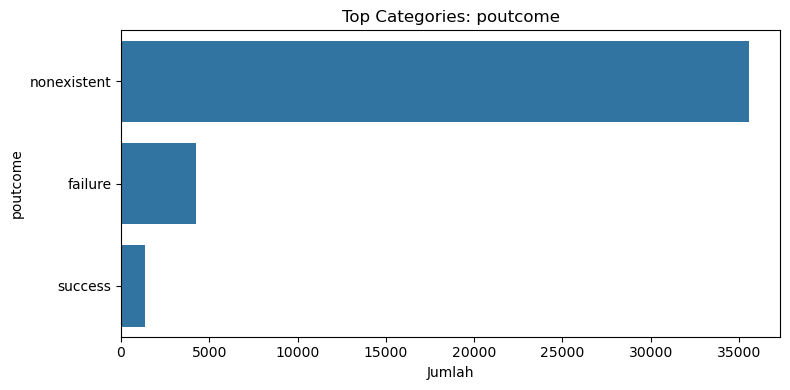

In [194]:
categorical_features = [c for c in cat_cols if c != "y"]

for col in categorical_features:
    counts = df[col].value_counts().head(10)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.values, y=counts.index)
    plt.title(f"Top Categories: {col}")
    plt.xlabel("Jumlah")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## **4.2 Bivariate Analysis**

### 4.2.1 Numerical vs Subscription

In [195]:
subscription_group = df.groupby("y")[numeric_cols].mean().T
subscription_group.columns = ["no", "yes"]
print("Rata-rata Fitur Numerik per Kelas Subscription:")
print(subscription_group.round(2))

Rata-rata Fitur Numerik per Kelas Subscription:
                               no      yes
age                         39.91    40.92
duration                   220.89   553.19
campaign                     2.38     2.00
pdays                        6.20     5.92
previous                     0.13     0.49
emp.var.rate                 0.25    -1.23
cons.price.idx              93.60    93.36
cons.conf.idx              -40.59   -39.80
euribor3m                    3.81     2.12
nr.employed               5176.18  5095.14
was_previously_contacted     0.01     0.21


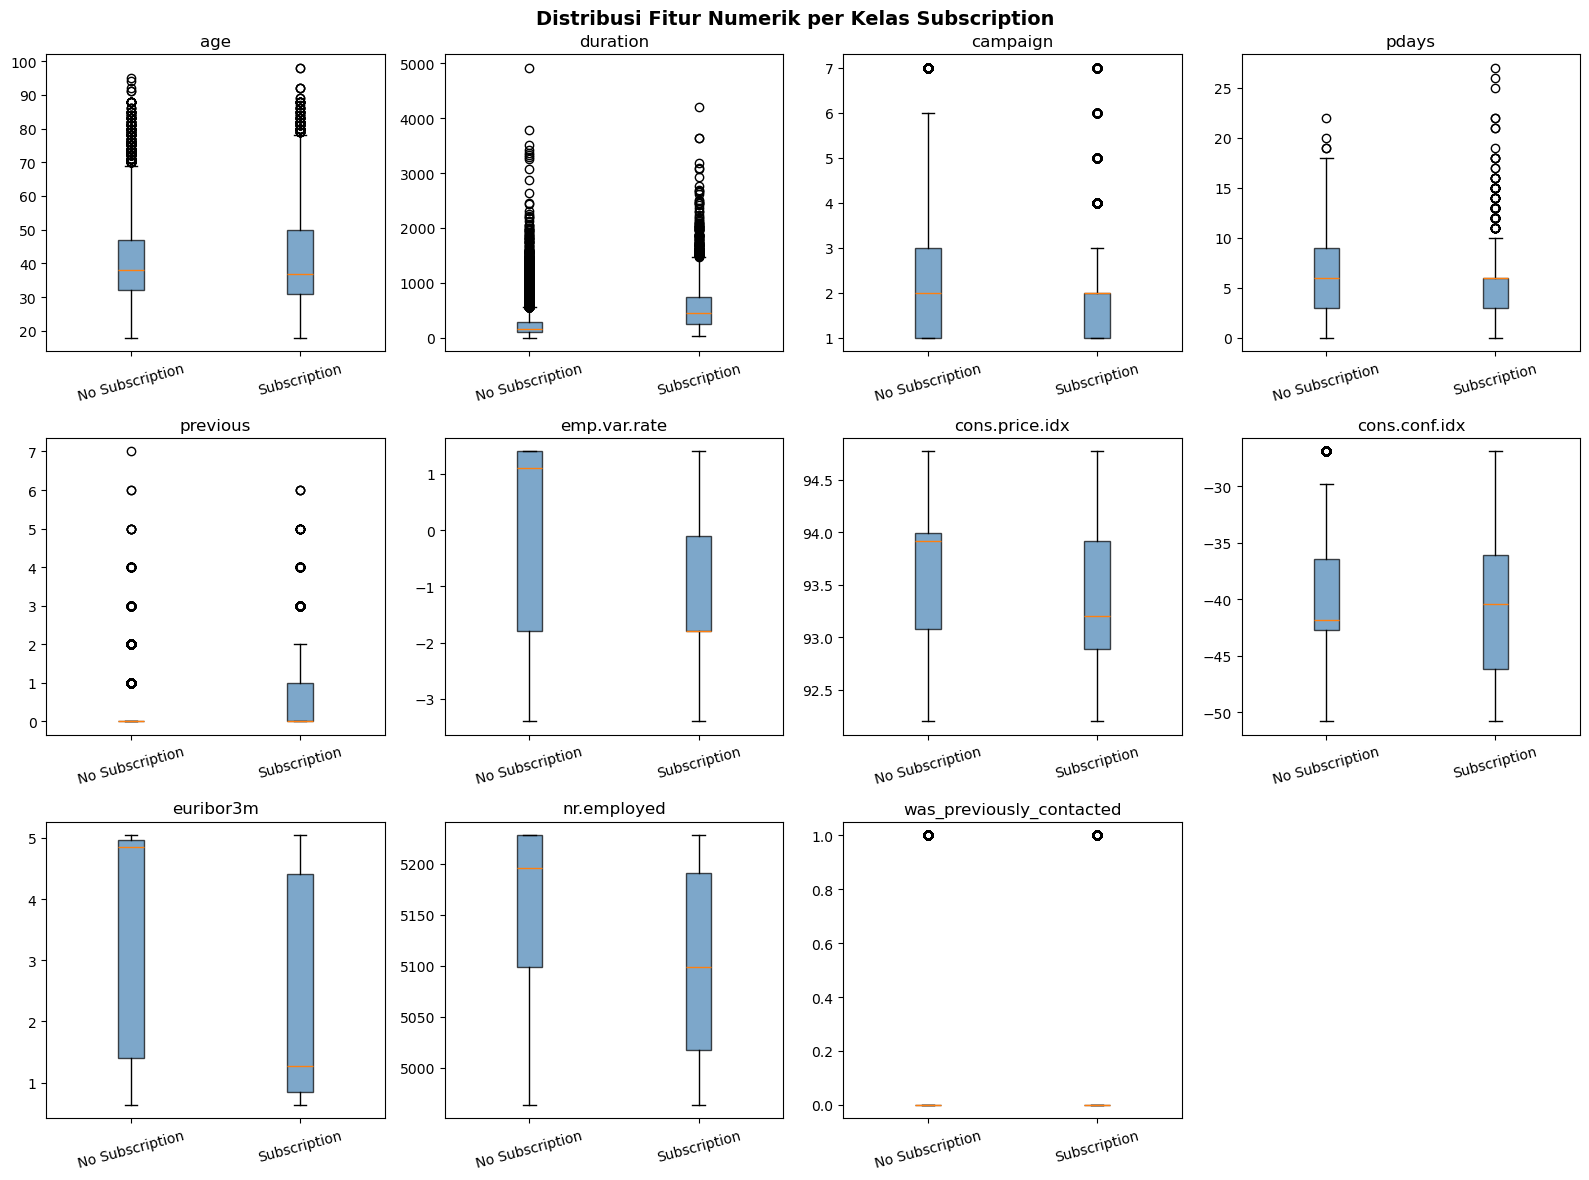

In [196]:
# Pastikan numeric_features berisi nama kolom numerik
n_cols = len(numeric_features)
n_rows = (n_cols + 3) // 4   # maksimal 4 per baris

fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sub_no = df[df["y"]=="no"][col].dropna()
    sub_yes = df[df["y"]=="yes"][col].dropna()
    
    axes[i].boxplot([sub_no, sub_yes],
                    labels=["No Subscription", "Subscription"],
                    patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.7))
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=15)

# Matikan axes kosong
for j in range(len(numeric_features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribusi Fitur Numerik per Kelas Subscription",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 4.2.2 Kategorikal vs Subscription

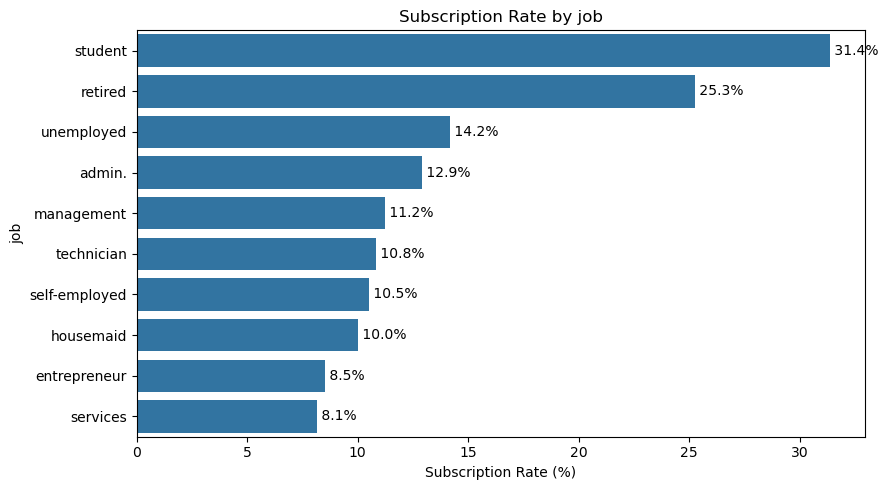

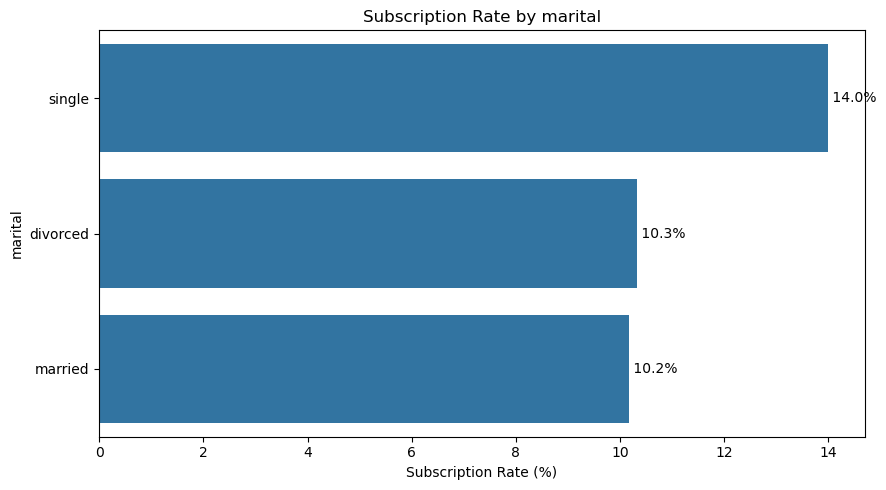

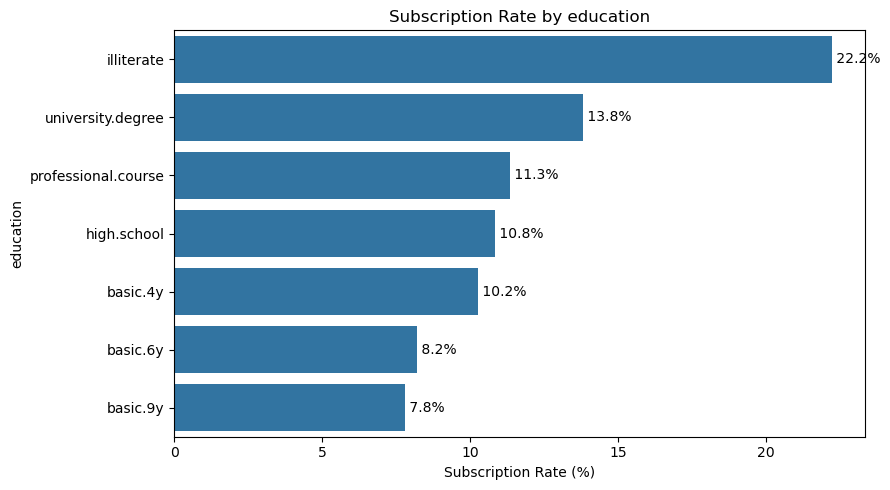

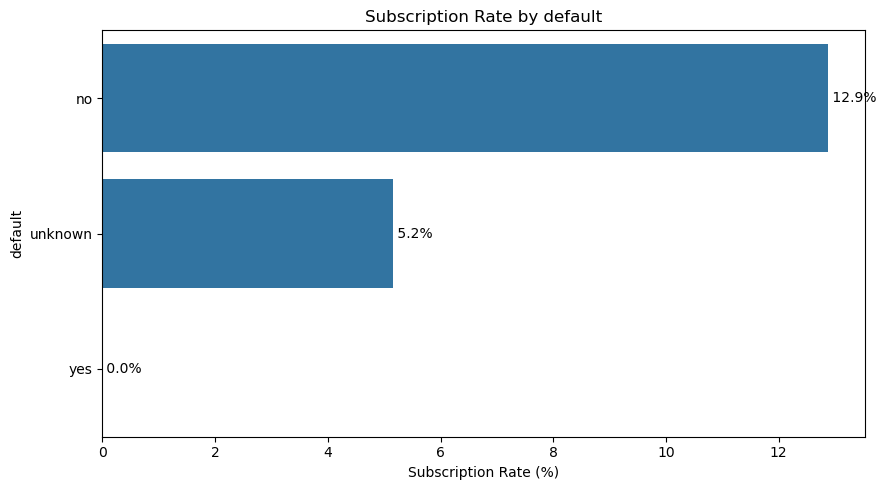

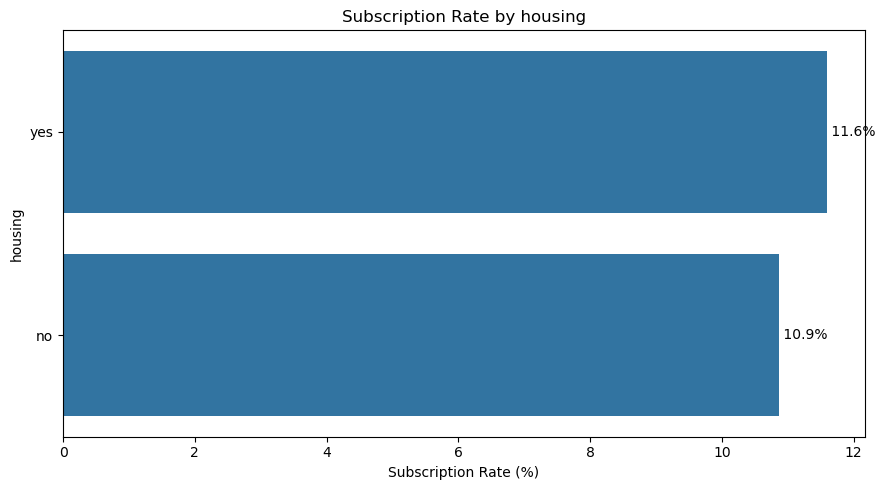

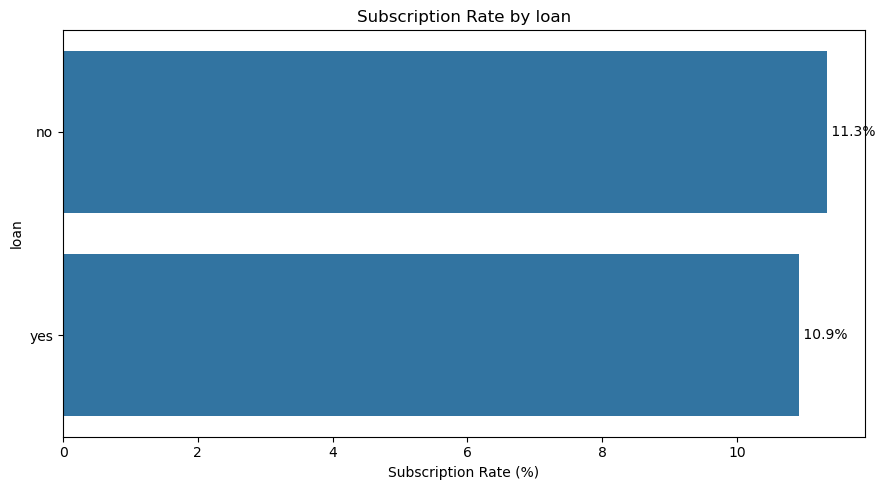

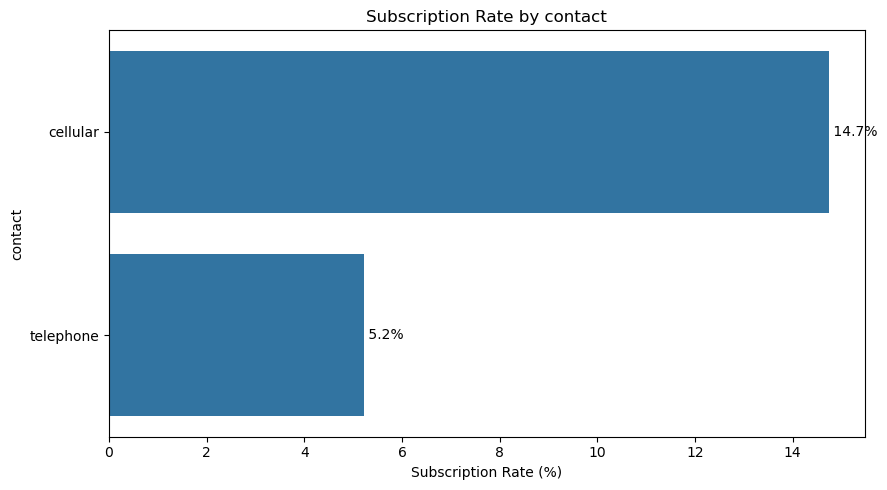

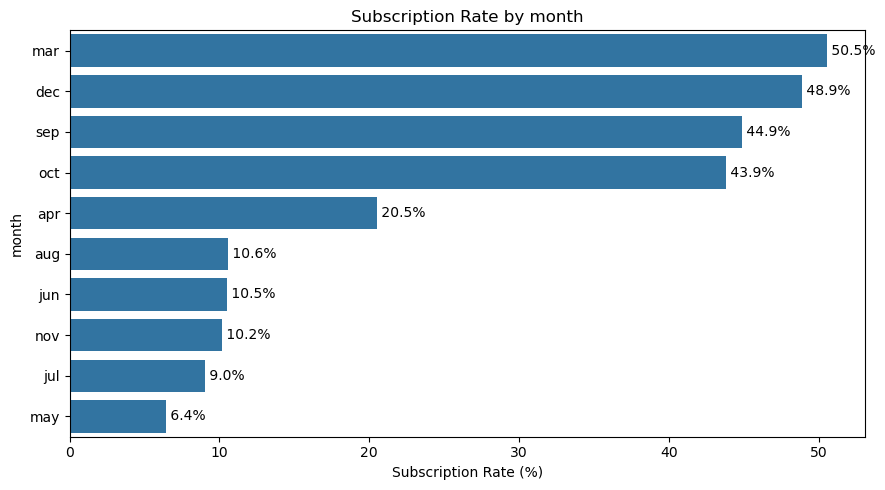

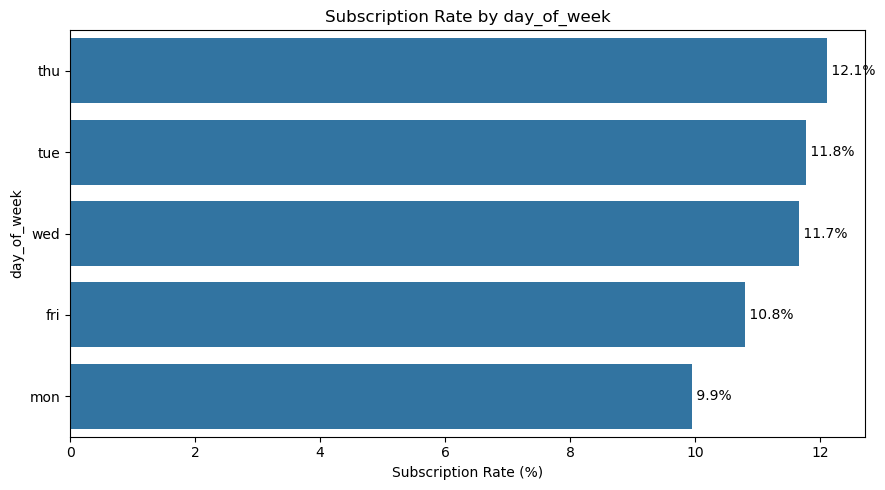

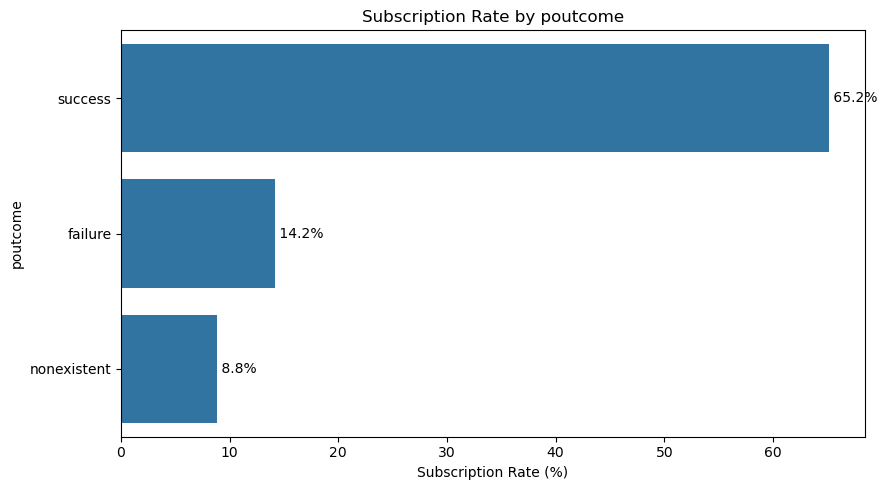

In [197]:
categorical_features = [c for c in cat_cols if c != "y"]
for col in categorical_features:

    # Hitung jumlah data per kategori
    count = df.groupby(col)["y"].count()

    # Hitung jumlah subscription (yes) per kategori
    yes_count = df.groupby(col)["y"].apply(
        lambda x: (x == "yes").sum()
    )

    # Hitung subscription rate
    rate = (yes_count / count * 100).round(2)

    # Gabungkan jumlah nasabah dan subscription rate
    result = pd.DataFrame({
        "Customer Count": count,
        "Subscription Rate (%)": rate
    })

    # Urutkan berdasarkan subscription rate
    result = result.sort_values(
        "Subscription Rate (%)",
        ascending=False
    ).head(10)

    plt.figure(figsize=(9, 5))

    ax = sns.barplot(
        data=result,
        x="Subscription Rate (%)",
        y=result.index
    )

    plt.title(f"Subscription Rate by {col}")
    plt.xlabel("Subscription Rate (%)")
    plt.ylabel(col)

    # Tambahkan label rate
    for i, value in enumerate(result["Subscription Rate (%)"]):
        ax.text(
            value,
            i,
            f" {value:.1f}%",
            va="center"
        )

    plt.tight_layout()
    plt.show()

## **4.3 Correlation & Multicollinearity Check**

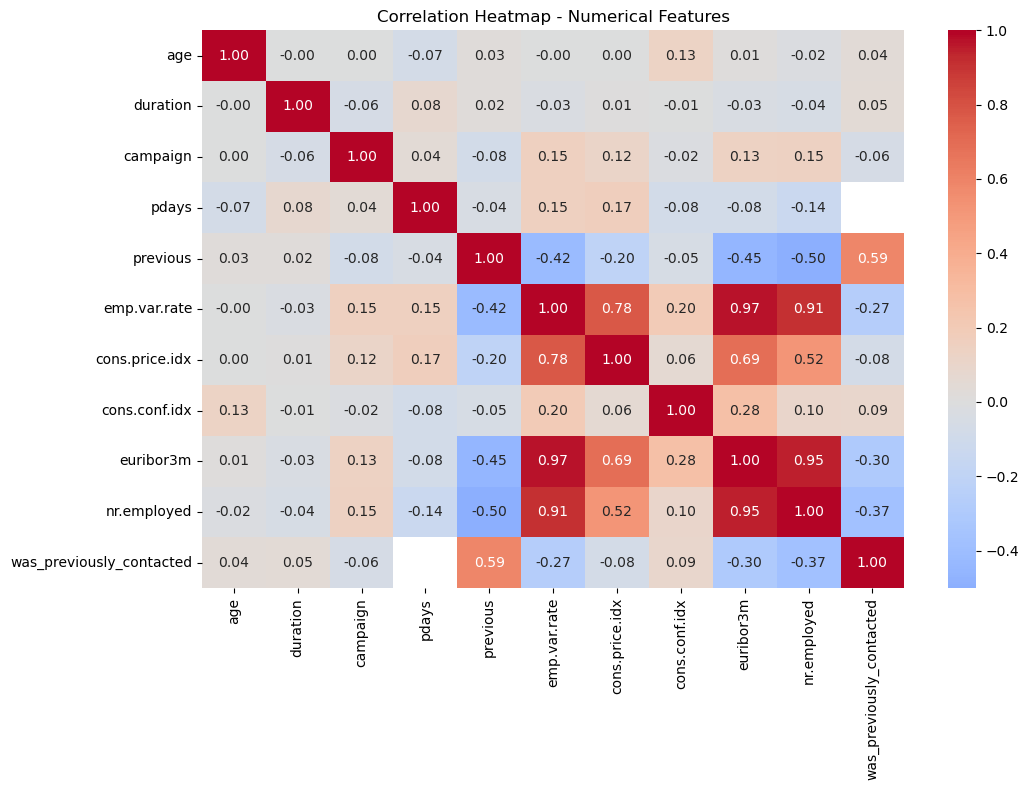

In [198]:
# Correlation heatmap
corr = df[numeric_features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()

# **Section 5. Data Preparation**

## **5.1 Initialization**

In [199]:
# Target encoding
df["y"] = df["y"].map({"no": 0, "yes": 1})

# define feature and target
feature = df.drop(columns="y")
target = df["y"]


 ## **5.2 Constructing Training and Testing Data**

In [200]:
x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target
)

# TODO: reset index
x_train = x_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
x_test  = x_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

print("\ny_train distribution:")

Train shape: (32933, 21)
Test shape : (8234, 21)

y_train distribution:


## **5.3 Handling Imbalanced Data**

In [201]:
# Cek distribusi kelas
print(df["y"].value_counts())
print(df['y'].value_counts(normalize=True) * 100)
print("Class imbalance terdeteksi (~89% kelas no, ~11% kelas yes).")
print("Strategi: SMOTE akan diterapkan di dalam Pipeline pada data training saja.")
print("SMOTE TIDAK diterapkan pada data testing agar evaluasi tetap realistis.")

y
0    36530
1     4637
Name: count, dtype: int64
y
0    88.736124
1    11.263876
Name: proportion, dtype: float64
Class imbalance terdeteksi (~89% kelas no, ~11% kelas yes).
Strategi: SMOTE akan diterapkan di dalam Pipeline pada data training saja.
SMOTE TIDAK diterapkan pada data testing agar evaluasi tetap realistis.


## **5.4 Data Transformation (Feature Engineering)**

In [202]:
# Numerical features
numeric_features = [
    c for c in x_train.select_dtypes(include=np.number).columns
]

# Categorical features
categorical_features = [
    c for c in x_train.select_dtypes(
        include=["object"]
    ).columns
]

# Binary feature
binary_features = [
    "was_previously_contacted"
]

# Jangan masukkan binary ke numerical pipeline
numeric_features = [
    c for c in numeric_features
    if c not in binary_features
]

print("Numerical:")
print(numeric_features)

print("\nBinary:")
print(binary_features)

print("\nCategorical:")
print(categorical_features)

Numerical:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Binary:
['was_previously_contacted']

Categorical:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [203]:
# Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
        ("binary", "passthrough", binary_features)
    ]
)

# base model with resampling
base_pipeline = ImbPipeline([
    ("fitur_engineering", preprocessor),
    ("fitur_resampling", SMOTE(random_state=RANDOM_STATE)),
    ("feature_selection", SelectKBest()),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE))
])

## **5.5 Feature Selection**

In [204]:
base_pipeline.fit(x_train, y_train)

,steps,"[('fitur_engineering', ...), ('fitur_resampling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [205]:
# 1. Ambil object yang sudah di fit
preprocessor_fitted = base_pipeline.named_steps["fitur_engineering"]
selector_fitted = base_pipeline.named_steps["feature_selection"]

# 2. Nama fitur setelah preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# 3. Mask fitur yang dipilih SelectBest
selected_mask = selector_fitted.get_support()

# 4. Gabungkan nama fitur yang lolos seleksi
selected_features = feature_names[selected_mask]

print(f"Jumlah fitur sebelum seleksi : {len(feature_names)}")
print(f"Jumlah fitur setelah seleksi : {len(selected_features)}")
print(selected_features)

Jumlah fitur sebelum seleksi : 59
Jumlah fitur setelah seleksi : 10
['num__duration' 'num__previous' 'num__emp.var.rate' 'num__euribor3m'
 'num__nr.employed' 'cat__contact_cellular' 'cat__contact_telephone'
 'cat__poutcome_nonexistent' 'cat__poutcome_success'
 'binary__was_previously_contacted']


## **5.6 Overview**

In [206]:
print("=" * 50)
print("RINGKASAN DATA PREPARATION")
print("=" * 50)
print(f"Training data : {x_train.shape[0]} baris x {x_train.shape[1]} kolom")
print(f"Testing data  : {x_test.shape[0]} baris x {x_test.shape[1]} kolom")
print(f"Jumlah fitur  : {len(feature)}")

RINGKASAN DATA PREPARATION
Training data : 32933 baris x 21 kolom
Testing data  : 8234 baris x 21 kolom
Jumlah fitur  : 41167


# **Section 6. Model Development**

## **6.1. Initialization**

In [207]:
# F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# scoring
scoring = {
    'recall'   : 'recall',
    'precision': 'precision',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc',
    'f2'       : f2_scorer
}

def run_cv(base_pipeline, x_train, y_train):
    """Jalankan cross-validation dan kembalikan ringkasan metrik."""
    results = cross_validate(base_pipeline, x_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    summary = {}
    for m in scoring:
        scores = results[f'test_{m}']
        summary[m] = {'mean': scores.mean(), 'std': scores.std()}
    return summary

print("Cross-Validation: StratifiedKFold (5 fold)")
print("Metrik: Recall, Precision, F1, F2, ROC-AUC")

Cross-Validation: StratifiedKFold (5 fold)
Metrik: Recall, Precision, F1, F2, ROC-AUC


In [208]:
cv_result = run_cv(
    base_pipeline,
    x_train,
    y_train
)

In [209]:
# save to dataframe
cv_summary = pd.DataFrame(cv_result).T
cv_summary

,mean,std
recall,0.847978,0.014349
precision,0.425459,0.006097
f1,0.566593,0.007496
roc_auc,0.926757,0.004173
f2,0.707424,0.010055


## **6.2 Developing the Model Pipeline**

In [210]:
def make_pipeline(model):
    """Buat ImbPipeline: preprocessor -> SMOTE -> model."""
    return ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote',        SMOTE(random_state=RANDOM_STATE)),
        ('model',        model)
    ])

print("Pipeline: preprocessor -> SMOTE -> model")
print("Keunggulan: preprocessing di-fit hanya pada training fold (no data leakage).")

Pipeline: preprocessor -> SMOTE -> model
Keunggulan: preprocessing di-fit hanya pada training fold (no data leakage).


In [211]:
# Initialize model
logreg   = LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced")
knn      = KNeighborsClassifier()
dt       = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
rf       = RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")
gb       = GradientBoostingClassifier(random_state=RANDOM_STATE)
adaboost = AdaBoostClassifier(random_state=RANDOM_STATE)

In [212]:
list_models = {
    "LogisticRegression"     : logreg,
    "KNN"                    : knn,
    "DecisionTreeClassifier" : dt,
    "RandomForestClassifier" : rf,
    "GradientBoost"          : gb,
    "AdaBoost"               : adaboost,
}

## **6.3 Model Benchmarking**

### 6.3.1 Model Benchmarking (with resampling)

In [220]:
# Benchmark model function
def benchmark_models(pipeline, list_models, x_train, y_train, 
                      scoring=f2_scorer, cv=5, random_state=RANDOM_STATE):
    """""
    Benchmark beberapa model classifier menggunakan cross-validation
    di atas satu pipeline yang sama (hanya step 'classifier' yang diganti).

    Parameters
    ----------
    pipeline : sklearn Pipeline
        Pipeline yang punya step bernama 'classifier' (mis. model_res_pipeline).
    list_models : dict
        {"nama_model": estimator, ...}
    x_train, y_train : array-like
        Data training.
    scoring : str
        Metric untuk cross_validate (default "f1").
    cv : int
        Jumlah fold untuk StratifiedKFold (default 5).
    random_state : int or None
        Untuk shuffle di StratifiedKFold, jika ingin reproducible.

    Returns
    -------
    pd.DataFrame
        Ringkasan mean & std train/test score per model, diurutkan
        berdasarkan mean_test_score tertinggi.
    """
    all_cv_result = []

    skf = StratifiedKFold(
        n_splits=cv,
        shuffle=random_state is not None,
        random_state=random_state
    )

    for name, model in list_models.items():
        classifier = pipeline.set_params(classifier=model)
        cv_result = cross_validate(
            estimator=classifier,
            X=x_train, y=y_train,
            cv=skf,
            scoring=scoring,
            return_train_score=True
        )
        all_cv_result.append({
            "name": name,
            "mean_train_score": np.mean(cv_result["train_score"]),
            "std_train_score": np.std(cv_result["train_score"]),
            "mean_test_score": np.mean(cv_result["test_score"]),
            "std_test_score": np.std(cv_result["test_score"])
        })

    df_result = pd.DataFrame(all_cv_result).sort_values(
        "mean_test_score", ascending=False
    ).reset_index(drop=True)

    return df_result

In [221]:
# With resampling
benchmark_models(
    base_pipeline, 
    list_models,
    x_train, 
    y_train, 
    scoring=f2_scorer,
    cv=5, 
    random_state=RANDOM_STATE
)

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,GradientBoost,0.757006,0.001685,0.747319,0.005525
1,AdaBoost,0.731205,0.003271,0.729338,0.007610
2,KNN,0.789426,0.002019,0.714199,0.010010
3,LogisticRegression,0.707896,0.003013,0.707424,0.010055
4,RandomForestClassifier,0.973798,0.001427,0.644394,0.012793
5,DecisionTreeClassifier,0.962808,0.002148,0.599221,0.018159


### 6.3.2 Model Ensamble Benchmarking

### 6.3.2.1 Various Type

In [222]:
# model initialization
voting = VotingClassifier(estimators=[("rf", rf), ("dt", dt), ("knn", knn)])
stacking = StackingClassifier(estimators=[("rf", rf), ("dt", dt), ("knn", knn)],
                              final_estimator=gb)

In [225]:
# benchmark process
benchmark_various = benchmark_models(pipeline=base_pipeline, list_models={"voting": voting, "stacking": stacking}, x_train=x_train,y_train=y_train,
                    scoring=f2_scorer,
                    cv=5,
                    random_state=RANDOM_STATE)

In [226]:
benchmark_various

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,stacking,0.939687,0.007473,0.695071,0.014977
1,voting,0.972092,0.001389,0.652329,0.014174
